Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments.

## Setup

In [2]:
!pip install nucleus-cdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 77.9 MB/s eta 0:

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [5]:
# # Mount Google Drive (run once per session; will prompt for auth on first run)
# from google.colab import drive
# drive.mount('/content/drive')

# # Specify file paths (adjust the folder path to match where these live in your Drive)
# data_file = "/content/drive/MyDrive/[path-to-your-devnote-folder]/20260506-111818-cytation3-pure-timecourse-gfp-Ctosol-lifetime-test-biotek-cdk.txt"
# platemap_file = "/content/drive/MyDrive/[path-to-your-devnote-folder]/20260506-platemap-Cytosol-Lifetime.csv"

# # Load data
# data, platemap = pr.load_platereader_data(
#     data_file=data_file,
#     platemap_file=platemap_file,
#     platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
# )

# # Checkout first few rows
# data.head()

# Specify file paths
data_file = "/20260506-111818-cytation3-pure-timecourse-gfp-Ctosol-lifetime-test-biotek-cdk.txt"
platemap_file = "/20260506-platemap-Cytosol-Lifetime.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Reader,Date,Experiment Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,49,B,2,GFP-F-G35,2026-05-06 11:21:00,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
1,0 days 00:05:00,B2,134,B,2,GFP-F-G35,2026-05-06 11:26:00,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
2,0 days 00:10:00,B2,1410,B,2,GFP-F-G35,2026-05-06 11:31:00,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
3,0 days 00:15:00,B2,4789,B,2,GFP-F-G35,2026-05-06 11:36:00,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
4,0 days 00:20:00,B2,9338,B,2,GFP-F-G35,2026-05-06 11:41:00,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10


## Plot Raw Curves

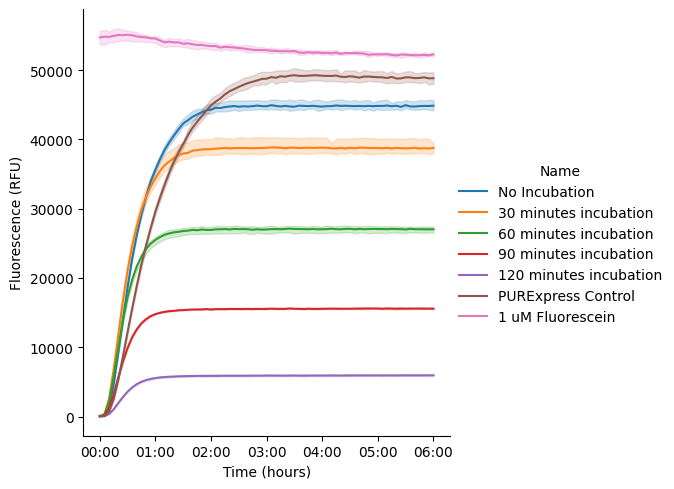

In [6]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics")

## Normalize Data

In [ ]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

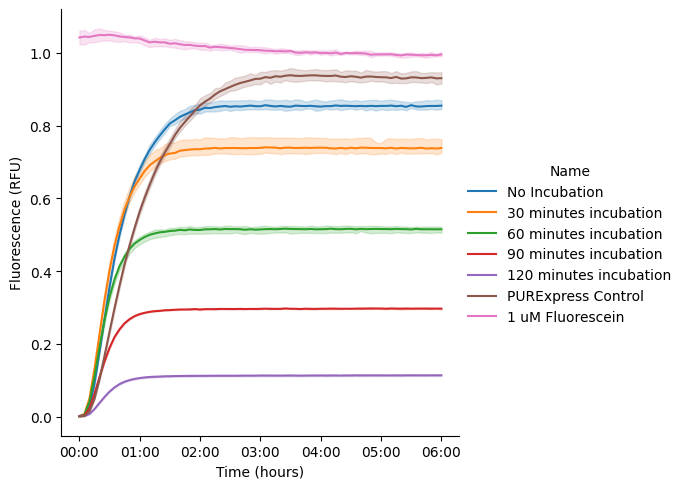

In [ ]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics-normalized")

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [ ]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                       \
                                                Time data_normalized  Max   
Name                  Well                                                  
No Incubation         B2   0 days 00:33:52.364973020            0.44 0.98   
                      B4   0 days 00:33:54.368546518            0.43 0.92   
                      B6   0 days 00:33:37.297194069            0.43 0.93   
30 minutes incubation D2   0 days 00:28:01.361558780            0.37 0.99   
                      D4   0 days 00:27:48.911777323            0.39 1.08   

                                                 Lag                  \
                                                Time data_normalized   
Name                  Well                                             
No Incubation         B2   0 days 00:07:00.295853232            0.05   
                      B4   0 days 00:05:50.077420022            0.04   
                      B6   0 days 00:05:39.614681497            0.04   
30 minutes incubation D2   0 days 00:05:40.925822398            0.05   
                      D4   0 days 00:06:07.526459736            0.06   

                                        Steady State                  \
                                                Time data_normalized   
Name                  Well                                             
No Incubation         B2   0 days 01:13:25.684549701            0.84   
                      B4   0 days 01:15:14.014768316            0.82   
                      B6   0 days 01:14:47.214086312            0.82   
30 minutes incubation D2   0 days 01:00:54.777173266            0.70   
                      D4   0 days 00:59:44.836604858            0.74   

                                                                          Fit  \
                                                                       params   
Name                  Well                                                      
No Incubation         B2    [0.8806531499165111, 4.466309733064684, 0.5645...   
                      B4    [0.8618759426756475, 4.274795425179619, 0.5651...   
                      B6    [0.8657418093741808, 4.291634410170598, 0.5603...   
30 minutes incubation D2    [0.7358908999165192, 5.371387682948765, 0.4670...   
                      D4    [0.7772535032026439, 5.532565877674917, 0.4635...   

                                                
                            R^2 drift good_fit  
Name                  Well                      
No Incubation         B2   0.99  0.01     True  
                      B4   0.99  0.01     True  
                      B6   0.99  0.01     True  
30 minutes incubation D2   1.00  0.01     True  
                      D4   0.99  0.01     True

## Visualize Fits on Individual Wells

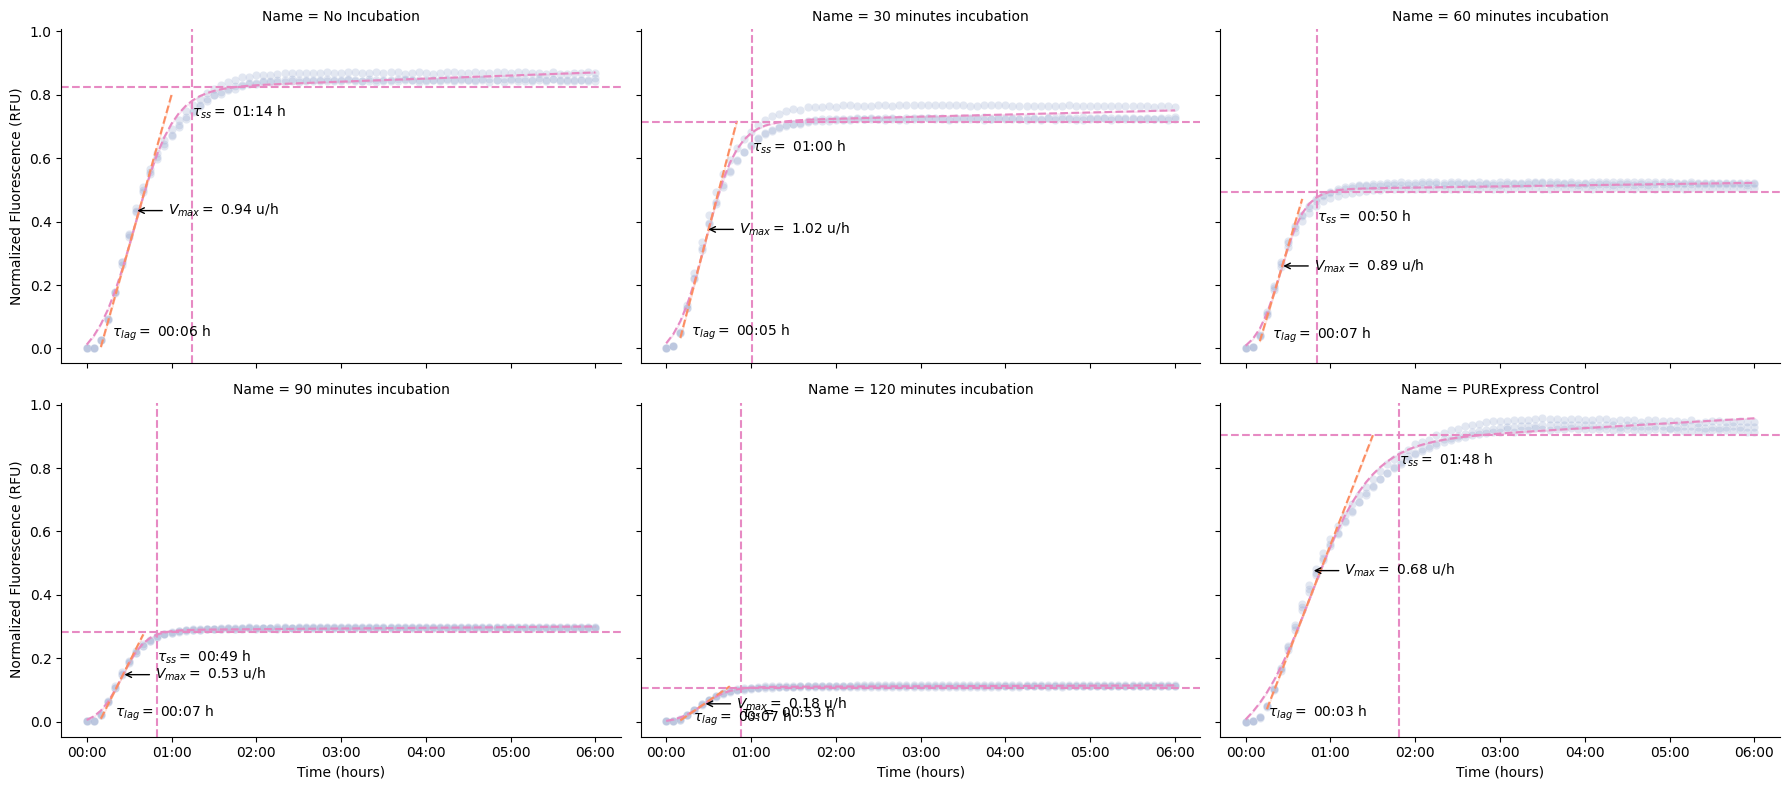

In [ ]:
# Plot kinetic fits
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

Calculating Kinetics


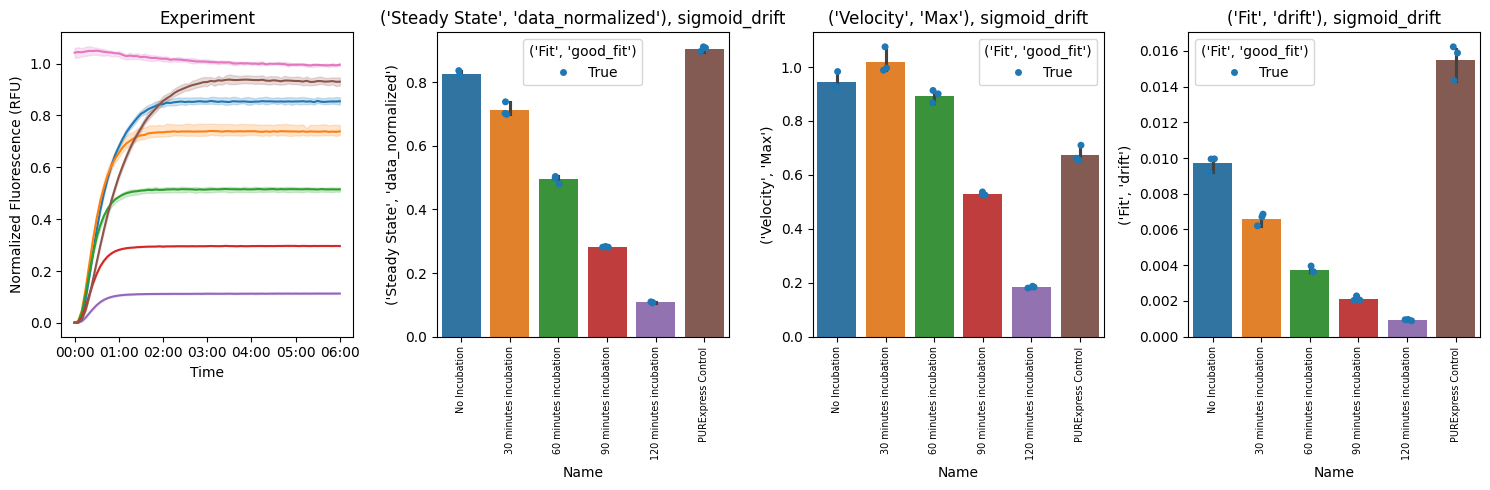

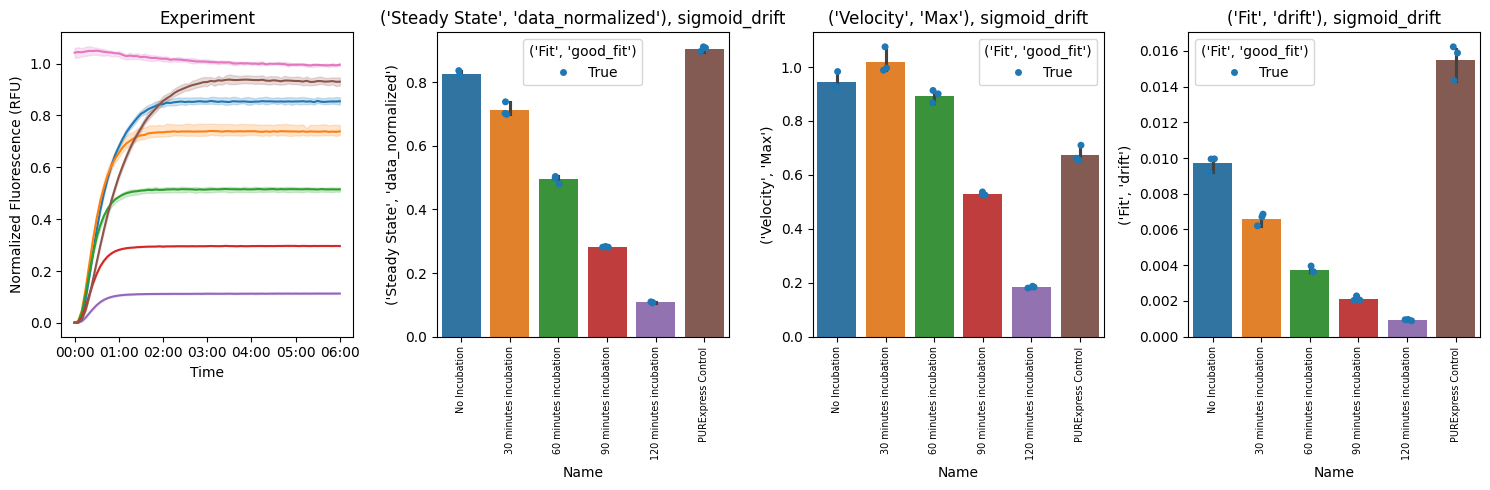

In [ ]:
pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants